# CPWL spectral operator through the matrix sign map
Convergence of a decomposition-free CPWL operator, built from the Newton–Schulz msgn surrogate, to the exact operator read off a signed SVD. Plot 1: relative Frobenius error against the iteration count k, one curve per degree D. Plot 2: for one D, the operator's output spectrum at a few values of k against the input singular values and the exact target profile. Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_operator import CPWLOperatorConfig, run_cpwl_convergence, run_cpwl_spectrum
%matplotlib inline

## Plot 1: error against iterations, several degrees D

In [34]:
cfg = CPWLOperatorConfig(
    m=64, n=48, rank=None, smin=1e-2,
    profile="clip", alpha=0.2, beta=0.5,
    degrees=[1, 2, 3, 4], k_max=20,
    D_show=3, k_show=[1, 2, 4, 8],
    dtype=torch.float64, seed=0,
)
res = run_cpwl_convergence(cfg)
res2 = run_cpwl_spectrum(cfg)

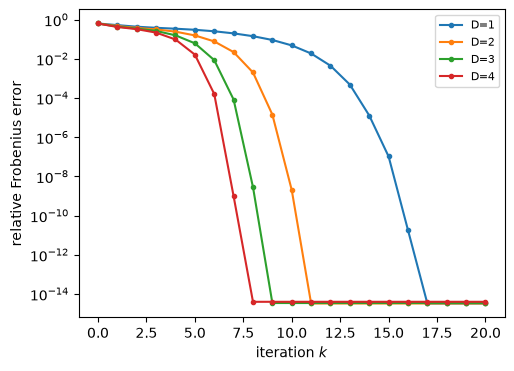

In [35]:
plots.plot_error_curves(res["error"], ylabel="relative Frobenius error");

## Plot 2: spectrum convergence, one degree D

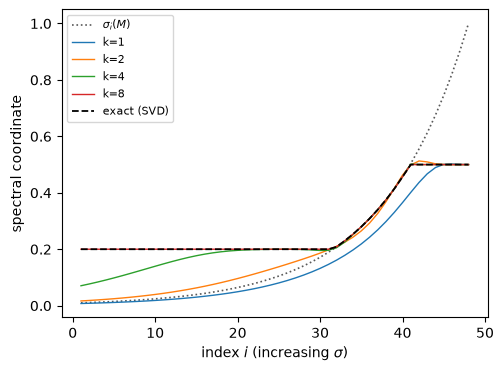

In [37]:
plots.plot_spectrum(res2["sigma"], res2["target"], res2["coords"], xaxis = "index");